# 激活函数

#### 什么是激活函数

用于将线性变换后的结果进行非线性变换，使得神经网络能够学习和表示复杂的函数关系。

#### 常见的激活函数有：
- **阶跃函数（Step Function）**：输出为0或1，适用于二分类问题，但不连续且不可微。
- **Sigmoid函数**：输出范围在0和1之间，适用于二分类问题，但容易出现梯度消失问题。
- **ReLU函数（Rectified Linear Unit）**：输出为输入的正部分，适用于深层神经网络，但可能导致神经元死亡问题。
- **Leaky ReLU函数**：ReLU的改进版本，允许输入的负部分有一个小的斜率，解决了ReLU的神经元死亡问题。
- **Tanh函数**：输出范围在-1和1之间，适用于二分类问题，但也容易出现梯度消失问题。
- **Softmax函数**：用于多分类问题，将输入转换为概率分布。

#### 激活函数的选择
- 隐藏层：ReLU函数最常用，在训练深层神经网络时表现良好
- 输出层：激活函数取决于任务类型：
  - 二分类问题：通常使用Sigmoid函数
  - 多分类问题：通常使用Softmax函数

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 阶跃函数

$
f(x) = \begin{cases}
0, & \ x \leq 0 \\
1, & \ x > 0
\end{cases}
$

In [2]:

## 接收numpy数组的函数实现

def step_function(x):
    y = x > 0
    return y.astype(int)

## 解释
#? 数组
x = np.array([-1.0, 1.0, 2.0])
print(x)

#? 表达式返回布尔数组
y = x > 0
print(y)

#? astype(int):将布尔值转换为整数，True变为1，False变为0
y = y.astype(int)
print(y)

[-1.  1.  2.]
[False  True  True]
[0 1 1]


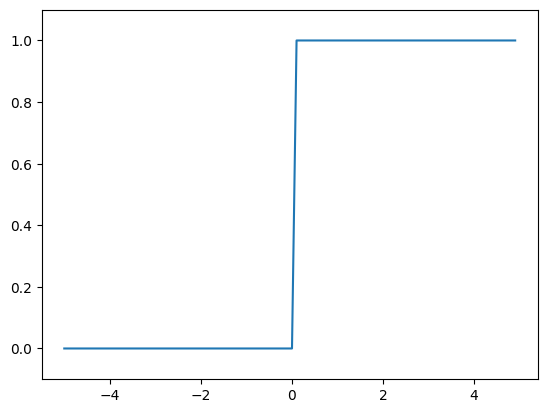

In [3]:
## 画阶跃函数图像
x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # 设置y轴范围
plt.show()

### sigmoid函数

$
f(x) = \frac{1}{1 + e^{-x}}
$

***sigmoid函数的优点：***
- 可微，为梯度计算提供便利
- 平滑性缓解剧烈震荡，避免无法收敛或收敛到次优解
- 连续输出，适合概率预测

***sigmoid函数的缺点：***
- 远端导数趋近于0，可能导致梯度消失问题

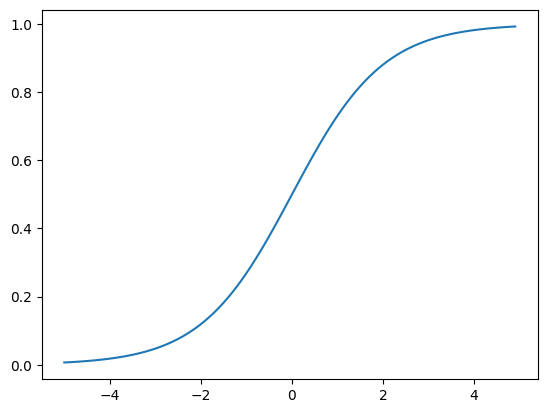

In [4]:

## Sigmoid函数实现

def sigmoid(x):
    return 1/ (1 + np.exp(-x))

## Sigmoid函数图像
x = np.arange(-5.0,5.0,0.1)
y = sigmoid(x)
plt.plot(x,y)
plt.show()

### ReLU函数
$
f(x) = \begin{cases}
x, & \ x > 0 \\
0, & \ x \leq 0
\end{cases}
$

***ReLU函数的优点：***
- 计算简单，效率高
- 大于0时导数恒为1，避免梯度消失问题
- 小于0输出0，引入稀疏性，减小参数互相依赖，降低过拟合风险

***ReLU函数的缺点：***
- 负部分恒为0，可能导致神经元死亡问题

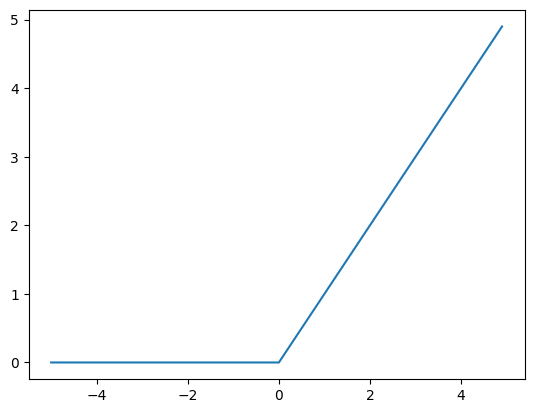

In [5]:

## ReLU函数实现

def relu(x):
    return np.maximum(0,x)

## ReLU函数图像
x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.show() 

### Leaky ReLU函数
$
f(x) = \begin{cases}
x, & \ x > 0 \\
\alpha x, & \ x \leq 0
\end{cases}
$
其中$\alpha$是一个小的常数（如0.01）

***Leaky ReLU函数的优点：***
- 允许负部分有一个小的斜率，解决了ReLU的神经元死亡问题
- 保持了ReLU在正部分的优点

***Leaky ReLU函数的缺点：***
- 可能引入一些噪声，影响模型的稳定性

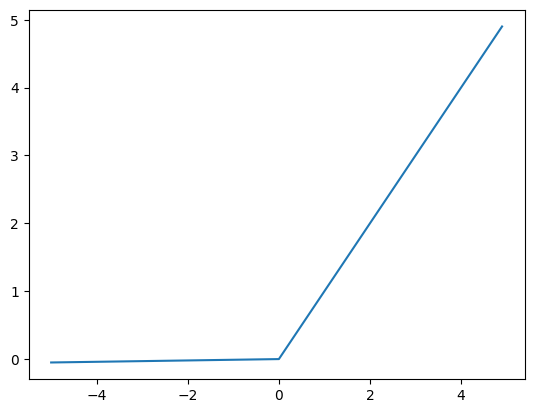

In [6]:

## 函数实现
def leaky_relu(x):
    return np.maximum(0.01*x, x)

## Leaky ReLU函数图像
x = np.arange(-5.0, 5.0, 0.1)
y = leaky_relu(x)
plt.plot(x, y)
plt.show()

### Tanh函数
$
f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$

***Tanh函数的优点：***
- 输出范围在-1和1之间，适合二分类问题
- 中心对称，均值为0，有助于数据的归一化

***Tanh函数的缺点：***
- 远端导数趋近于0，可能导致梯度消失问题
- 大量exp运算，计算效率低


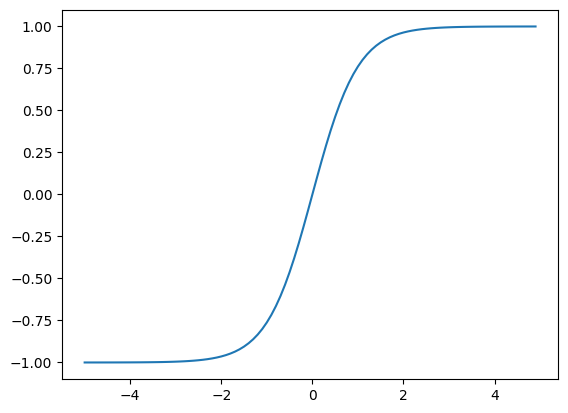

In [7]:

## 函数实现
def tanh(x):
    return np.tanh(x)

## 图像
x = np.arange(-5.0, 5.0, 0.1)
y = tanh(x)
plt.plot(x, y)
plt.show()

### softmax函数
$
f(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$

***Softmax函数的优点：***
- 将输入转换为概率分布，适用于多分类问题

***Softmax函数的缺点：***
- 可能导致数值不稳定，尤其是输入值较大时，容易出现溢出问题


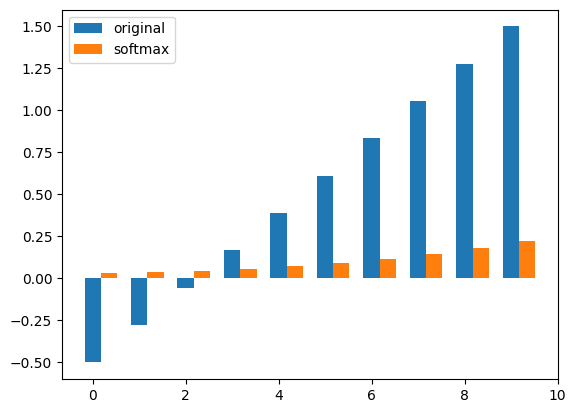

In [ ]:

## 函数实现
def softmax(x):
    c = np.max(x)  # 防止溢出
    exp_x = np.exp(x - c)
    sum_exp_x = np.sum(exp_x)
    return exp_x / sum_exp_x

## Softmax函数图像
width = 0.35
x = np.arange(0,10,1)
y1 = np.linspace(-0.5, 1.5, 10)
y2 = softmax(y1)
plt.bar(x, y1,width,label='original')
plt.bar(x + width, y2,width,label='softmax')
plt.xticks(x + width / 2, [f'{i}' for i in x])
plt.legend()
plt.show()